#### **Задание #1**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

#### Импортируем библиотеки и объявляем необходимые константы

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [117]:
RANDOM_STATE: int = 716
TRAIN_SIZE: float = 0.7
TEST_SIZE: float = 0.3
TARGET_VALUE: str = "Weight"

DEGREES_FOR_POLYNOMIALS: list[int] = [1, 2, 3, 4]
NUMERIC_COLUMNS: list[str] = ["Length1", "Length2", "Length3", "Height", "Width"]
ENCODE_COLUMNS: list[str] = ["Species_Parkki", "Species_Perch", "Species_Pike", "Species_Roach", "Species_Smelt", "Species_Whitefish"]

PATH_TO_DATASET: Path = Path("../data/fish.csv")

#### Загрузка и обработка датасета `fish.csv`

In [118]:
fish_dataframe = pd.read_csv(PATH_TO_DATASET)
fish_dataframe.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [119]:
fish_dataframe = pd.get_dummies(fish_dataframe, columns=["Species"], drop_first=True, dtype=int)
fish_dataframe.head()

,Weight,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,242.0,23.2,25.4,30.0,11.5200,4.0200,0,0,0,0,0,0
1,290.0,24.0,26.3,31.2,12.4800,4.3056,0,0,0,0,0,0
2,340.0,23.9,26.5,31.1,12.3778,4.6961,0,0,0,0,0,0
3,363.0,26.3,29.0,33.5,12.7300,4.4555,0,0,0,0,0,0
4,430.0,26.5,29.0,34.0,12.4440,5.1340,0,0,0,0,0,0


#### Создание выборки тестовых данных

In [120]:
X = fish_dataframe.drop(columns=[TARGET_VALUE])
y = fish_dataframe[TARGET_VALUE]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

#### Обучение классической модели линейной регрессии

Для того, чтобы узнать и выявить статистически переобучение модели, используем критерий Колмогорова-Смирнова

$H_0$ - выборки получены из одного и того же распределения

$H_1$ - выборки из разных распределений

In [121]:
linear_regression_errors = dict() 

for degree in DEGREES_FOR_POLYNOMIALS:
    model = LinearRegression(fit_intercept=True)
    poly = PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False)
    
    X_train_poly = poly.fit_transform(X_train[NUMERIC_COLUMNS])
    X_train_poly = np.hstack([X_train_poly, X_train[ENCODE_COLUMNS]])

    X_test_poly = poly.transform(X_test[NUMERIC_COLUMNS])
    X_test_poly = np.hstack([X_test_poly, X_test[ENCODE_COLUMNS]])

    model.fit(X_train_poly, y_train)

    train_predict = model.predict(X_train_poly)
    test_predict = model.predict(X_test_poly)

    train_errors = np.abs(y_train - train_predict)
    test_errors = np.abs(y_test - test_predict)

    stat_result = stats.ks_2samp(train_errors, test_errors)

    train_mae = np.mean(train_errors)
    test_mae = np.mean(test_errors)

    linear_regression_errors[degree] = {
        "train_mae": train_mae,
        "test_mae": test_mae
    }

    print(f"D = {stat_result.statistic}, p_value = {stat_result.pvalue}")

    if stat_result.pvalue < 0.05:
        print("Reject H0, distributions are different")
    else:
        print("Accept H0, distributions are the same")

    print(f"degree = {degree} | Train MAE = {train_mae}")
    print(f"degree = {degree} | Test MAE = {test_mae}\n")

D = 0.12274774774774774, p_value = 0.6398735317596111
Accept H0, distributions are the same
degree = 1 | Train MAE = 70.53338032041053
degree = 1 | Test MAE = 71.67686065447246

D = 0.15484234234234234, p_value = 0.35371815689953146
Accept H0, distributions are the same
degree = 2 | Train MAE = 27.303229689080613
degree = 2 | Test MAE = 41.04702470348841

D = 0.38569819819819817, p_value = 5.5783648399657626e-05
Reject H0, distributions are different
degree = 3 | Train MAE = 14.887708472380934
degree = 3 | Test MAE = 48.15402355597837

D = 0.9819819819819819, p_value = 1.8196138680022473e-38
Reject H0, distributions are different
degree = 4 | Train MAE = 0.45045394444319337
degree = 4 | Test MAE = 912.4099913804034



#### Визуализация MAE после обучения модели

Можно заметить как при увеличении степени для `PolynomialFeatures` проявляется эффект переобучения, что подтверждается также статистическим анализом распределений ошибок Train/Test при помощи критерия Колмогорова-Смирнова

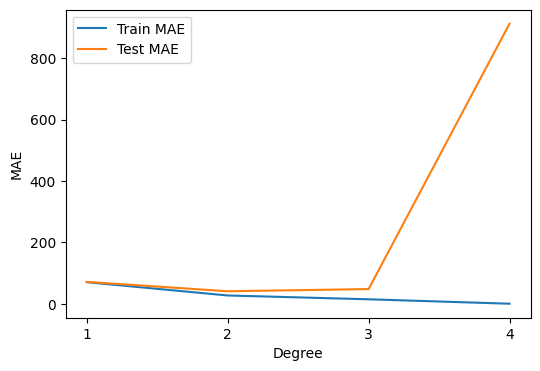

In [122]:
linear_regression_errors = pd.DataFrame(linear_regression_errors)

plt.figure(figsize=(6, 4))

plt.plot(DEGREES_FOR_POLYNOMIALS, linear_regression_errors.iloc[0], label="Train MAE")
plt.plot(DEGREES_FOR_POLYNOMIALS, linear_regression_errors.iloc[1], label="Test MAE")

plt.xticks(DEGREES_FOR_POLYNOMIALS)
plt.xlabel("Degree")
plt.ylabel("MAE")

plt.legend()
plt.grid(False)
plt.show()